<a href="https://colab.research.google.com/github/DiegoFmDev/CALCULO_III-Proyecto-Final/blob/main/Agente_Creador_de_Historias_Infantiles_Personalizadas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Agente Creador de Historias Infantiles
Personalizadas**

INTEGRANTES:


*   hilmer mostajo mamani
*   jhan marco gutierrez flores
*   diego fernando mamani quispe



In [ ]:
!pip install -q google-generativeai pydantic fastapi uvicorn pyngrok diffusers transformers accelerate

In [ ]:
import json
import time
from typing import List, Dict, Optional
from pydantic import BaseModel, Field

# Variables de estado (mock) para controlar el progreso
# Esto será útil cuando lo conectemos a la interfaz gráfica
estado_actual = "Inicializado"

print("✅ Dependencias importadas correctamente. Entorno listo.")

✅ Dependencias importadas correctamente. Entorno listo.


In [ ]:
# Definir la estructura exacta garantiza que el frontend (Flutter) y el backend (Colab) hablen el mismo idioma.

class PerfilNino(BaseModel):
    nombre: str
    edad: int
    intereses: List[str] = Field(description="Ej: dinosaurios, el espacio, princesas")
    valor_ensenar: str = Field(description="Ej: la amistad, compartir, valentía")

class Escena(BaseModel):
    numero: int
    texto_narrativo: str
    prompt_imagen: str
    url_imagen: Optional[str] = None

class CuentoGenerado(BaseModel):
    titulo: str
    historia_completa: str
    escenas: List[Escena]

print("✅ Modelos de datos definidos.")

✅ Modelos de datos definidos.


In [ ]:
def obtener_preferencias(datos_crudos: dict) -> PerfilNino:
    """
    Paso 1: Recibe los datos del frontend, los valida y los convierte en un objeto tipado.
    """
    print("-> Validando preferencias del niño...")
    # Pydantic automáticamente valida que los datos cumplan con el modelo
    perfil = PerfilNino(**datos_crudos)
    return perfil

def generar_historia(perfil: PerfilNino) -> str:
    """
    Paso 2: (MOCK) Aquí llamaremos a Gemini para crear el cuento completo.
    """
    print(f"-> Generando historia para {perfil.nombre}...")
    time.sleep(1) # Simulamos el tiempo de espera de la API

    historia_mock = f"Había una vez un niño llamado {perfil.nombre}. Le encantaban los {perfil.intereses[0]}."
    return historia_mock

def dividir_escenas(historia: str) -> CuentoGenerado:
    """
    Paso 3: (MOCK) Aquí Gemini analizará la historia y devolverá el JSON estructurado con las escenas.
    """
    print("-> Dividiendo la historia en escenas y generando prompts visuales...")
    time.sleep(1)

    # Simulamos la respuesta estructurada de Gemini
    cuento_mock = CuentoGenerado(
        titulo="La Gran Aventura",
        historia_completa=historia,
        escenas=[
            Escena(
                numero=1,
                texto_narrativo="Había una vez...",
                prompt_imagen="Ilustración infantil 2d, estilo acuarela, un niño sonriente"
            )
        ]
    )
    return cuento_mock

def generar_ilustraciones(cuento: CuentoGenerado) -> CuentoGenerado:
    """
    Paso 4: (MOCK) Iteramos sobre las escenas y llamamos al motor de imágenes.
    """
    print("-> Generando ilustraciones (esto suele tardar)...")

    for escena in cuento.escenas:
        print(f"   Generando imagen para escena {escena.numero}...")
        time.sleep(2) # Simulamos el renderizado de la imagen
        # Simulamos que la imagen se guardó y obtenemos su ruta
        escena.url_imagen = f"/ruta/local/imagen_escena_{escena.numero}.png"

    return cuento

def pipeline_agente_cuentos(datos_entrada: dict):
    """
    El orquestador maestro que une todas las piezas.
    """
    print("=== INICIANDO AGENTE DE CUENTOS ===")

    # 1. Validar entrada
    perfil = obtener_preferencias(datos_entrada)

    # 2. Generar texto
    historia_cruda = generar_historia(perfil)

    # 3. Estructurar y crear prompts
    cuento_estructurado = dividir_escenas(historia_cruda)

    # 4. Generar imágenes
    cuento_final = generar_ilustraciones(cuento_estructurado)

    print("=== CUENTO GENERADO CON ÉXITO ===")
    return cuento_final

print("✅ Funciones core definidas. Pipeline listo para pruebas.")

✅ Funciones core definidas. Pipeline listo para pruebas.


In [ ]:
input_prueba = {
    "nombre": "Leo",
    "edad": 5,
    "intereses": ["robots", "el espacio"],
    "valor_ensenar": "el trabajo en equipo"
}

resultado = pipeline_agente_cuentos(input_prueba)

# Mostramos el resultado final en formato JSON para verificar
print("\n--- RESULTADO FINAL JSON ---")
print(resultado.model_dump_json(indent=2))

=== INICIANDO AGENTE DE CUENTOS ===
-> Validando preferencias del niño...
-> Generando historia para Leo...
-> Dividiendo la historia en escenas y generando prompts visuales...
-> Generando ilustraciones (esto suele tardar)...
   Generando imagen para escena 1...
=== CUENTO GENERADO CON ÉXITO ===

--- RESULTADO FINAL JSON ---
{
  "titulo": "La Gran Aventura",
  "historia_completa": "Había una vez un niño llamado Leo. Le encantaban los robots.",
  "escenas": [
    {
      "numero": 1,
      "texto_narrativo": "Había una vez...",
      "prompt_imagen": "Ilustración infantil 2d, estilo acuarela, un niño sonriente",
      "url_imagen": "/ruta/local/imagen_escena_1.png"
    }
  ]
}


In [ ]:
import google.generativeai as genai
from google.colab import userdata

try:
    # Intenta leer la llave desde los secretos de Colab
    GOOGLE_API_KEY = userdata.get('GEMINI_API_KEY')
    genai.configure(api_key=GOOGLE_API_KEY)
    print("✅ API Key de Gemini cargada desde los secretos de Colab.")
except:
    print("⚠️ No se encontró 'GEMINI_API_KEY' en los secretos.")
    GOOGLE_API_KEY = input("Pega tu API Key de Gemini aquí: ")
    genai.configure(api_key=GOOGLE_API_KEY)

# Solución al error 404: Usamos el alias dinámico de la última versión
# o una versión moderna confirmada.
modelo_texto = genai.GenerativeModel('gemini-2.5-flash')

print("✅ Modelo instanciado correctamente.")

✅ API Key de Gemini cargada desde los secretos de Colab.
✅ Modelo instanciado correctamente.


In [ ]:
# Muestra los modelos de generación de texto disponibles para tu API Key
for m in genai.list_models():
  if 'generateContent' in m.supported_generation_methods:
    print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.5-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-pr

In [ ]:
import json

def generar_historia(perfil: PerfilNino) -> str:
    print(f"-> [Gemini] Escribiendo la historia para {perfil.nombre}...")

    prompt = f"""
    Eres un experto escritor de cuentos infantiles. Escribe un cuento corto, mágico y envolvente
    (máximo 300 palabras) para un niño llamado {perfil.nombre} de {perfil.edad} años.
    Sus intereses son: {', '.join(perfil.intereses)}.
    El cuento debe enseñar este valor: {perfil.valor_ensenar}.

    Devuelve SOLO el texto del cuento. No incluyas introducciones ni saludos.
    """

    respuesta = modelo_texto.generate_content(prompt)
    return respuesta.text

def dividir_escenas(historia: str) -> CuentoGenerado:
    print("-> [Gemini] Analizando el texto y creando prompts visuales...")

    prompt = f"""
    Analiza el siguiente cuento infantil y divídelo en 3 a 4 escenas principales.
    Para cada escena, extrae el fragmento de texto exacto y crea un 'prompt_imagen'
    altamente descriptivo en inglés (optimizado para un modelo de IA de imágenes).

    Regla para el prompt_imagen: Siempre debe empezar con "Children's book illustration,
    2d vector art, flat colors, modern minimalist, cute".

    Cuento:
    {historia}

    Devuelve el resultado ESTRICTAMENTE en formato JSON siguiendo esta estructura exacta:
    {{
        "titulo": "Título creativo del cuento",
        "historia_completa": "El cuento completo original",
        "escenas": [
            {{
                "numero": 1,
                "texto_narrativo": "fragmento de la historia",
                "prompt_imagen": "descripción visual en inglés",
                "url_imagen": null
            }}
        ]
    }}
    """

    # Forzamos la salida en JSON nativo
    respuesta = modelo_texto.generate_content(
        prompt,
        generation_config={"response_mime_type": "application/json"}
    )

    # Convertimos el JSON string al objeto Pydantic que definimos en el Bloque 2
    datos_json = json.loads(respuesta.text)
    return CuentoGenerado(**datos_json)

print("✅ Funciones core actualizadas con inteligencia de Gemini.")

✅ Funciones core actualizadas con inteligencia de Gemini.


In [ ]:
input_prueba = {
    "nombre": "Mateo",
    "edad": 6,
    "intereses": ["perros espaciales", "naves de cartón"],
    "valor_ensenar": "la curiosidad"
}

print("=== INICIANDO PRUEBA REAL CON IA ===")
resultado_agente = pipeline_agente_cuentos(input_prueba)

print("\n--- RESULTADO GENERADO POR GEMINI ---")
print(resultado_agente.model_dump_json(indent=2))

=== INICIANDO PRUEBA REAL CON IA ===
=== INICIANDO AGENTE DE CUENTOS ===
-> Validando preferencias del niño...
-> [Gemini] Escribiendo la historia para Mateo...
-> [Gemini] Analizando el texto y creando prompts visuales...
-> Generando ilustraciones (esto suele tardar)...
   Generando imagen para escena 1...
   Generando imagen para escena 2...
   Generando imagen para escena 3...
   Generando imagen para escena 4...
=== CUENTO GENERADO CON ÉXITO ===

--- RESULTADO GENERADO POR GEMINI ---
{
  "titulo": "Mateo y Astro: La Aventura Cósmica del Botón Secreto",
  "historia_completa": "Mateo, con sus manos pequeñas pero expertas, terminaba de pintar su nave espacial de cartón. ¡Era la más magnífica del universo! Tenía alas de cajas de cereales y un asiento suave de almohada. “¡Despegando en 3, 2, 1…!” susurró, haciendo ruidos de cohete.\n\nDe repente, un brillo suave apareció en el centro de su panel de control de cartón. ¿Qué era eso? Mateo, con sus ojos bien abiertos de curiosidad, se ace

In [ ]:
from diffusers import StableDiffusionPipeline
import torch
import os

print("⏳ Descargando y cargando el modelo de imágenes (esto puede tardar 1-2 minutos la primera vez)...")

# Usamos Stable Diffusion v1.5 por ser rápido y excelente para ilustraciones
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda") # Enviamos el modelo a la GPU T4

# Optimización para consumir menos memoria de video
pipe.enable_attention_slicing()

# Creamos una carpeta para guardar las imágenes generadas
os.makedirs("imagenes_cuento", exist_ok=True)

print("✅ Motor de imágenes cargado en la GPU y listo para dibujar.")

⏳ Descargando y cargando el modelo de imágenes (esto puede tardar 1-2 minutos la primera vez)...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

✅ Motor de imágenes cargado en la GPU y listo para dibujar.


In [ ]:
def generar_ilustraciones(cuento: CuentoGenerado) -> CuentoGenerado:
    print("-> [Stable Diffusion] Iniciando el dibujado de las escenas...")

    for escena in cuento.escenas:
        # Extraemos el prompt que creó Gemini en el paso anterior
        prompt_visual = escena.prompt_imagen
        print(f"   🎨 Dibujando Escena {escena.numero}... (aprox 10-15 segundos)")

        # Generamos la imagen con 25 pasos (buen balance entre velocidad y calidad)
        imagen = pipe(prompt_visual, num_inference_steps=25).images[0]

        # Guardamos la imagen en nuestra carpeta
        ruta_archivo = f"imagenes_cuento/escena_{escena.numero}.png"
        imagen.save(ruta_archivo)

        # Actualizamos nuestro objeto con la ruta real
        escena.url_imagen = ruta_archivo

        # ¡Muy importante! Limpiamos la memoria caché de la tarjeta gráfica
        # para que Colab no se quede sin memoria en la siguiente iteración
        torch.cuda.empty_cache()

    print("-> [Stable Diffusion] ¡Todas las ilustraciones generadas con éxito!")
    return cuento

print("✅ Función de generación de ilustraciones actualizada con IA real.")

✅ Función de generación de ilustraciones actualizada con IA real.


=== INICIANDO AGENTE DE CUENTOS ===
-> Validando preferencias del niño...
-> [Gemini] Escribiendo la historia para Mateo...
-> [Gemini] Analizando el texto y creando prompts visuales...


[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (89 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['his room is tidy with hints of toys . soft , warm lighting .']


-> [Stable Diffusion] Iniciando el dibujado de las escenas...
   🎨 Dibujando Escena 1... (aprox 10-15 segundos)


  0%|          | 0/25 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['conveys a sense of wonder and gentle magic .']


...

-> [Stable Diffusion] ¡Todas las ilustraciones generadas con éxito!
=== CUENTO GENERADO CON ÉXITO ===



# 📖 Mateo y el Cohete de la Curiosidad

*Una historia para Mateo*

### Escena 1

> Mateo tenía un secreto. En su habitación, un cohete de cartón hecho con cajas viejas no era solo un juguete; era su nave espacial de los sueños. Una tarde, con sus botas de lluvia como botas espaciales y un colador en la cabeza, Mateo se subió.

"¡Tres, dos, uno, despegue!" susurró. Cerró los ojos, imaginando las estrellas.

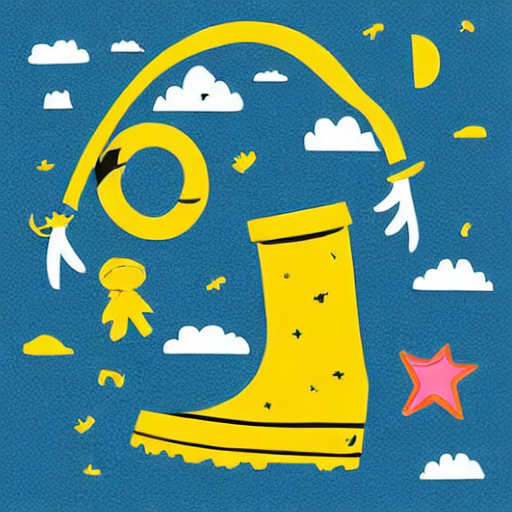


---



### Escena 2

> Esta vez, algo fue diferente. Sintió un suave empujón. Cuando abrió los ojos, ¡su nave de cartón flotaba entre nubes de algodón y estrellas que parpadeaban como luciérnagas gigantes!

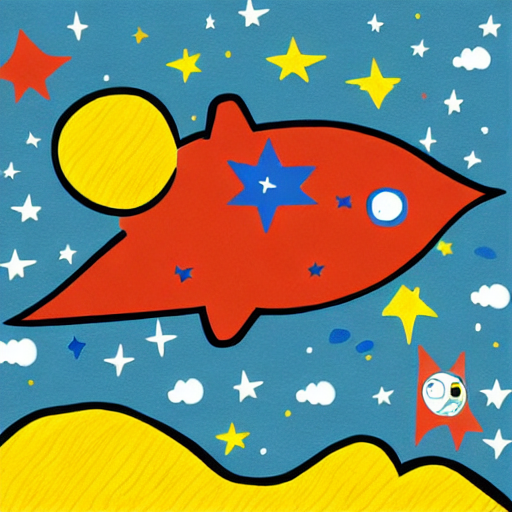


---



### Escena 3

> Un ladrido suave lo sobresaltó. Flotando junto a su ventana de cartón había un perrito. Tenía el pelaje azul brillante y un collar con una pequeña estrella fugaz. Era Cosmo, el perro espacial de la curiosidad. Cosmo inclinó su cabeza, invitándolo a mirar. Mateo, sin dudarlo, empujó la ventana. Cosmo lo guio hacia un planeta cercano, un lugar donde los árboles tenían hojas de cristal y las flores cantaban melodías suaves.

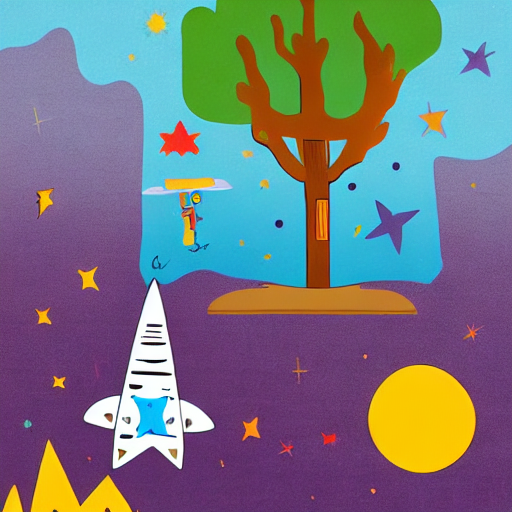


---



### Escena 4

> "¿Qué más habrá?" pensó Mateo, con un cosquilleo de emoción. La curiosidad era un motor en su pecho, empujándolo a descubrir. Aunque fue solo un sueño o magia, Mateo supo que siempre valía la pena mirar un poco más allá, porque el universo de la curiosidad era infinito y lleno de maravillas. Y solo necesitaba su nave de cartón para explorarlo.

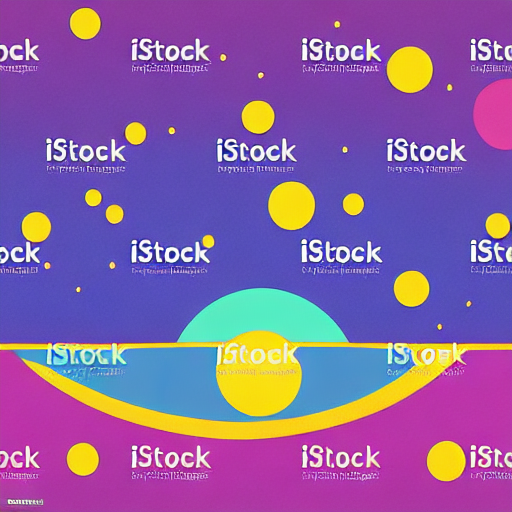


---



In [ ]:
from IPython.display import display, Image as IPImage, Markdown

# Usamos nuestros datos de prueba
input_prueba = {
    "nombre": "Mateo",
    "edad": 6,
    "intereses": ["perros espaciales", "naves de cartón"],
    "valor_ensenar": "la curiosidad"
}

# 1. EJECUTAMOS TODO EL AGENTE
resultado_final = pipeline_agente_cuentos(input_prueba)

# 2. MOSTRAMOS EL RESULTADO EN PANTALLA
print("\n" + "="*50)
display(Markdown(f"# 📖 {resultado_final.titulo}"))
display(Markdown(f"*Una historia para {input_prueba['nombre']}*"))
print("="*50 + "\n")

for escena in resultado_final.escenas:
    # Mostramos el texto
    display(Markdown(f"### Escena {escena.numero}"))
    display(Markdown(f"> {escena.texto_narrativo}"))

    # Mostramos la imagen generada
    if escena.url_imagen and os.path.exists(escena.url_imagen):
        display(IPImage(filename=escena.url_imagen, width=500))
    print("\n---\n")

In [ ]:
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pyngrok import ngrok
import nest_asyncio
import uvicorn
from google.colab import userdata

# 1. Inicializamos la aplicación FastAPI
app = FastAPI(title="API Agente de Cuentos Infantiles")

# 2. Configuramos CORS (permite que la app móvil se comunique sin bloqueos de seguridad)
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)

# 3. Creamos el Endpoint que recibirá los datos desde la app móvil
@app.post("/generar_cuento")
async def generar_cuento_api(perfil: PerfilNino):
    print(f"\n🔔 ¡NUEVA SOLICITUD DESDE LA APP! Creando cuento para: {perfil.nombre}")

    # Transformamos el objeto Pydantic en diccionario para nuestra función
    datos_crudos = perfil.model_dump()

    # Ejecutamos toda nuestra magia
    resultado_final = pipeline_agente_cuentos(datos_crudos)

    # FastAPI automáticamente convierte nuestra respuesta en JSON para la app
    return resultado_final

print("✅ Servidor API configurado. Listo para arrancar.")

✅ Servidor API configurado. Listo para arrancar.


In [ ]:
import threading
import uvicorn
from pyngrok import ngrok
from google.colab import userdata

# 1. Autenticamos ngrok
try:
    NGROK_TOKEN = userdata.get('NGROK_TOKEN')
    ngrok.set_auth_token(NGROK_TOKEN)
except:
    print("⚠️ No se encontró 'NGROK_TOKEN' en los secretos.")
    NGROK_TOKEN = input("Pega tu Authtoken de ngrok aquí: ")
    ngrok.set_auth_token(NGROK_TOKEN)

# 2. Cerramos cualquier túnel previo por limpieza
ngrok.kill()

# 3. Abrimos el túnel en el puerto 8000
tunnel = ngrok.connect(8000)
url_publica = tunnel.public_url

print("\n" + "="*60)
print("🚀 ¡TU BACKEND ESTÁ VIVO EN INTERNET!")
print(f"🔗 URL PARA FLUTTER: {url_publica}/generar_cuento")
print(f"📖 PRUEBA MANUAL: {url_publica}/docs")
print("="*60 + "\n")

# 4. Envolvemos el arranque del servidor en una función
def iniciar_servidor():
    # Desactivamos los logs extra para no ensuciar la consola de Colab
    uvicorn.run(app, host="0.0.0.0", port=8000, log_level="warning")

# 5. Ejecutamos el servidor en un hilo (Thread) en segundo plano
hilo_servidor = threading.Thread(target=iniciar_servidor, daemon=True)
hilo_servidor.start()

print("✅ Servidor corriendo en segundo plano. Ya puedes abrir la URL de prueba manual.")

⚠️ No se encontró 'NGROK_TOKEN' en los secretos.
Pega tu Authtoken de ngrok aquí: 3FmKLnaserU7Kz1Fp6J1HyBvDuD_Rvr3KtQTPveuG6HWJoQH

🚀 ¡TU BACKEND ESTÁ VIVO EN INTERNET!
🔗 URL PARA FLUTTER: https://extent-drinkable-rockfish.ngrok-free.dev/generar_cuento
📖 PRUEBA MANUAL: https://extent-drinkable-rockfish.ngrok-free.dev/docs

✅ Servidor corriendo en segundo plano. Ya puedes abrir la URL de prueba manual.


In [ ]:
!pip install -q python-docx

ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use


In [ ]:
from docx import Document
from docx.shared import Inches
import os
from fastapi.staticfiles import StaticFiles

# 1. Creamos la carpeta donde se guardarán los documentos
os.makedirs("exportaciones", exist_ok=True)

# 2. Le decimos a FastAPI que exponga esta carpeta a internet
# Para que la app móvil pueda descargar el archivo usando una URL
app.mount("/descargas", StaticFiles(directory="exportaciones"), name="descargas")

def exportar_cuento_word(cuento: CuentoGenerado) -> str:
    """Toma el JSON del cuento y genera un archivo físico .docx"""
    print("-> [Exportación] Maquetando el documento de Word...")

    doc = Document()

    # Título principal
    doc.add_heading(cuento.titulo, 0)

    # Iteramos sobre las escenas para agregar el texto y la ilustración
    for escena in cuento.escenas:
        doc.add_heading(f"Escena {escena.numero}", level=2)
        doc.add_paragraph(escena.texto_narrativo)

        # Si la imagen existe, la insertamos en el Word
        if escena.url_imagen and os.path.exists(escena.url_imagen):
            doc.add_picture(escena.url_imagen, width=Inches(5.0))

    # Limpiamos el título para que sea un nombre de archivo válido
    nombre_limpio = "".join(c if c.isalnum() else "_" for c in cuento.titulo)
    ruta_guardado = f"exportaciones/{nombre_limpio}.docx"

    doc.save(ruta_guardado)
    print(f"✅ Documento guardado en: {ruta_guardado}")
    return nombre_limpio

# 3. Actualizamos nuestro endpoint para incluir la generación del archivo
@app.post("/generar_cuento")
async def generar_cuento_api(perfil: PerfilNino):
    print(f"\n🔔 ¡NUEVA SOLICITUD! Creando cuento para: {perfil.nombre}")

    # Ejecutamos el pipeline de IA (Texto + Imágenes)
    resultado_final = pipeline_agente_cuentos(perfil.model_dump())

    # Exportamos a Word
    nombre_archivo = exportar_cuento_word(resultado_final)

    # Construimos la URL de descarga dinámica usando tu túnel de ngrok actual
    url_descarga_word = f"{url_publica}/descargas/{nombre_archivo}.docx"

    # Devolvemos el JSON estructurado + el enlace directo al archivo
    return {
        "datos_cuento": resultado_final.model_dump(),
        "url_documento": url_descarga_word
    }

print("✅ Función de exportación a Word integrada y API actualizada.")

✅ Función de exportación a Word integrada y API actualizada.
